# MNIST Hardware Inference on AUP-ZU3
Layer 1 (784→128 matmul + ReLU) runs on the FPGA PL via HLS overlay.
Layer 2 (128→10) and softmax remain on the PS.

## 1. Load Overlay

In [10]:
from pynq import Overlay, allocate
import numpy as np
import matplotlib.pyplot as plt
import time

overlay = Overlay('layer1.bit')
ip = overlay.layer1_hw_0
print(ip.register_map)

RegisterMap {
  CTRL = Register(AP_START=0, AP_DONE=0, AP_IDLE=1, AP_READY=0, RESERVED_1=0, AUTO_RESTART=0, RESERVED_2=0, INTERRUPT=0, RESERVED_3=0),
  GIER = Register(Enable=0, RESERVED=0),
  IP_IER = Register(CHAN0_INT_EN=0, CHAN1_INT_EN=0, RESERVED_0=0),
  IP_ISR = Register(CHAN0_INT_ST=0, CHAN1_INT_ST=0, RESERVED_0=0),
  x_1 = Register(x=write-only),
  x_2 = Register(x=write-only),
  W_1 = Register(W=write-only),
  W_2 = Register(W=write-only),
  b_1 = Register(b=write-only),
  b_2 = Register(b=write-only),
  y_1 = Register(y=write-only),
  y_2 = Register(y=write-only),
  input_size = Register(input_size=write-only),
  output_size = Register(output_size=write-only)
}


## 2. Load Weights

In [ ]:
W1 = np.load('w1.npy')  # (784, 128) float32
b1 = np.load('b1.npy')  # (128,) float32
W2 = np.load('w2.npy')  # (128, 10) float32
b2 = np.load('b2.npy')  # (10,) float32

print('W1:', W1.shape, '  b1:', b1.shape)
print('W2:', W2.shape, '  b2:', b2.shape)

# Scale factor to convert float weights to int32
# The same scale is applied to input pixels so math stays consistent
SCALE = 1000

# Convert weights and biases to int32 for hardware
W1_int = (W1.T * SCALE).astype(np.int32)   # (128, 784)
b1_int = (b1   * SCALE * SCALE).astype(np.int32)  # (128,) — bias is in scaled^2 units

W1: (784, 128)   b1: (128,)
W2: (128, 10)   b2: (10,)


## 3. Load MNIST Test Data

In [12]:
def load_idx_images(path):
    with open(path, 'rb') as f:
        f.read(4)
        n     = int.from_bytes(f.read(4), 'big')
        rows  = int.from_bytes(f.read(4), 'big')
        cols  = int.from_bytes(f.read(4), 'big')
        data  = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, rows, cols)

def load_idx_labels(path):
    with open(path, 'rb') as f:
        f.read(4)
        n    = int.from_bytes(f.read(4), 'big')
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data

x_test = load_idx_images('t10k-images.idx3-ubyte')
y_test = load_idx_labels('t10k-labels.idx1-ubyte')

# Flatten and scale to int32 — matches SCALE applied to weights
# (pixel / 255.0) * SCALE  →  pixel * SCALE / 255
x_test_int = (x_test.reshape(-1, 784).astype(np.int32) * SCALE) // 255

# Keep float version for SW layer 2 reference
x_test_flat = x_test.reshape(-1, 784).astype(np.float32) / 255.0

print(f'Test images: {x_test.shape}  |  Test labels: {y_test.shape}')

Test images: (10000, 28, 28)  |  Test labels: (10000,)


## 4. Allocate Buffers

In [13]:
x_buf = allocate(shape=(784,), dtype='i4')
W_buf = allocate(shape=(128 * 784,), dtype='i4')
b_buf = allocate(shape=(128,), dtype='i4')
y_buf = allocate(shape=(128,), dtype='i4')

# Copy weights
np.copyto(W_buf, W1_int.flatten())
np.copyto(b_buf, b1_int)

# Write weight/bias buffer addresses
ip.write(ip.register_map.W_1.address, W_buf.physical_address)
ip.write(ip.register_map.W_2.address, (W_buf.physical_address >> 32))
ip.write(ip.register_map.b_1.address, b_buf.physical_address)
ip.write(ip.register_map.b_2.address, (b_buf.physical_address >> 32))
ip.write(ip.register_map.y_1.address, y_buf.physical_address)
ip.write(ip.register_map.y_2.address, (y_buf.physical_address >> 32))
ip.write(ip.register_map.input_size.address,  784)
ip.write(ip.register_map.output_size.address, 128)

print('Buffers allocated and weights loaded.')

Buffers allocated and weights loaded.


## 5. Inference Functions

In [14]:
def softmax(x):
    e = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e / np.sum(e, axis=-1, keepdims=True)

def layer1_hw(x_int32):
    """Run one image through Layer 1 on the FPGA. Returns int32 array of shape (128,)."""
    np.copyto(x_buf, x_int32)

    ip.write(ip.register_map.x_1.address, x_buf.physical_address)
    ip.write(ip.register_map.x_2.address, (x_buf.physical_address >> 32))

    # Start kernel and poll ap_done
    ip.write(0x00, 0x01)
    while True:
        if ip.read(0x00) != 1:
            break

    return np.array(y_buf).copy()

def forward_pass_hw(x_int32):
    """Full forward pass for one image. Layer 1 on HW, Layer 2 + softmax on PS."""
    # Layer 1 on FPGA — result is int32 in scaled^2 units
    a1_int = layer1_hw(x_int32)

    # Convert back to float for Layer 2
    a1_float = a1_int.astype(np.float32) / (SCALE * SCALE)

    # Layer 2 + softmax on PS (identical to software version)
    return softmax(a1_float @ W2 + b2)

## 6. Run 30 Sample Images and Compare Timing

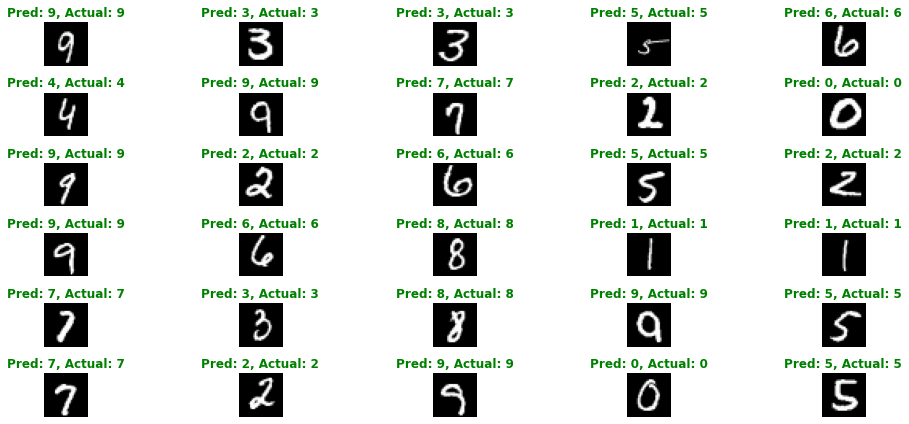


Prediction Summary:
Correctly predicted: 30 / 30

Timing (HW Layer 1 + SW Layer 2):
  Total (30 images): 44.5431 ms
  Per image: 1.4848 ms


In [20]:
num_samples = 30
indices = np.random.choice(len(x_test_int), num_samples, replace=False)

# Time the hardware forward pass
t0 = time.perf_counter()
predictions = np.array([forward_pass_hw(x_test_int[i]) for i in indices])
t1 = time.perf_counter()

predicted_labels = np.argmax(predictions, axis=1)
total_ms = (t1 - t0) * 1000
per_image_ms = total_ms / num_samples

# Show grid of images
fig, axes = plt.subplots(6, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    image = x_test[indices[idx]].reshape(28, 28)
    ax.imshow(image, cmap='gray')

    predicted = predicted_labels[idx]
    actual = y_test[indices[idx]]
    color = 'green' if predicted == actual else 'red'

    ax.set_title(f'Pred: {predicted}, Actual: {actual}', color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print('\nPrediction Summary:')
print(f'Correctly predicted: {np.sum(predicted_labels == y_test[indices])} / {num_samples}')
print(f'\nTiming (HW Layer 1 + SW Layer 2):')
print(f'  Total ({num_samples} images): {total_ms:.4f} ms')
print(f'  Per image: {per_image_ms:.4f} ms')

## 7. Full Test Set Accuracy

In [17]:
all_predictions = np.array([np.argmax(forward_pass_hw(x_test_int[i])) for i in range(len(x_test_int))])
accuracy = np.sum(all_predictions == y_test) / len(y_test)
print(f'Test accuracy: {accuracy:.2%}')

Test accuracy: 97.81%


## 8. Layer 1 Timing Breakdown

In [18]:
# Time just the HW (no Layer 2)
img_int = x_test_int[0]

N = 100
t0 = time.perf_counter()
for _ in range(N):
    layer1_hw(img_int)
t1 = time.perf_counter()

hw_layer1_ms = (t1 - t0) * 1000 / N
print(f'HW Layer 1 only (avg over {N} runs): {hw_layer1_ms:.4f} ms per image')

HW Layer 1 only (avg over 100 runs): 1.1835 ms per image
